<a href="https://colab.research.google.com/github/yashc2003/ML_DL_Practice_Projects/blob/main/Diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import required python labrary

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [ ]:
df = pd.read_csv("/content/pima-indians-diabetes.data.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/pima-indians-diabetes.data.csv'

Assign appropriate column name to the dataset




In [ ]:
df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
              'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Display first five records

In [ ]:
print("\nFirst Five Record")
print(df.head())

Display last five records

In [ ]:
print("\nLast Five Record")
print(df.tail())

In [ ]:
print(df.shape)

In [ ]:
print(df.info)

In [ ]:
print(df.describe())

In [ ]:
print(df.isnull().sum())

Separete input(x) and output(y)

In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

Split dataset into training and testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

 Feature Scaling

In [ ]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Build ANN Model

In [ ]:
model = Sequential()

model.add(Dense(16, activation='relu', input_dim=8))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

Compile Model

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [ ]:
sgd_optimizer = SGD(learning_rate=0.01)

model.compile(optimizer=sgd_optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])


Train Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Plot Accuracy Graph

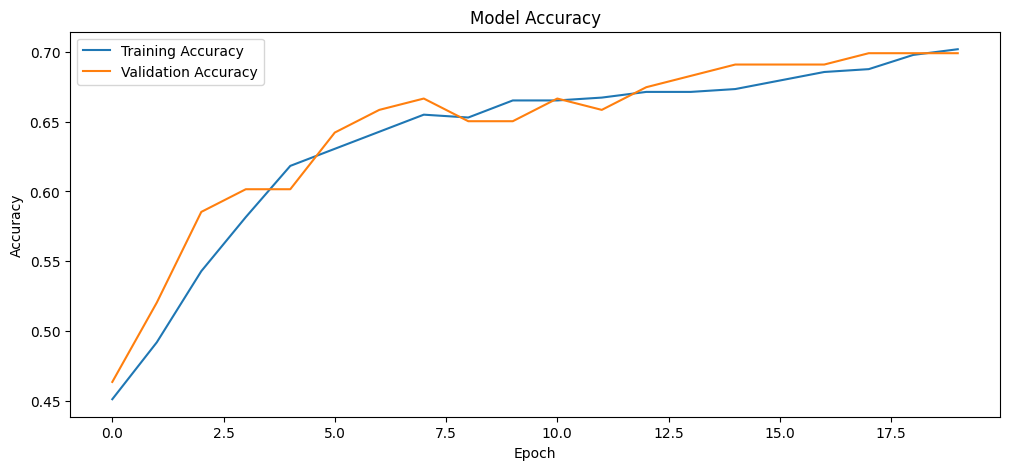

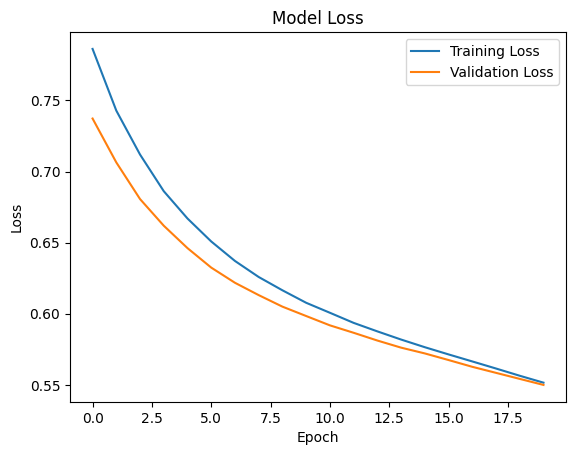

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Plot Loss Graph

Evaluate model

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6753 - loss: 0.5599 

Test Loss: 0.5599403977394104
Test Accuracy: 0.6753246784210205


 Predict Class Labels

In [ ]:

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


confusion_matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)



Confusion Matrix
[[92  5]
 [45 12]]


Classification Report

In [ ]:
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.67      0.95      0.79        97
           1       0.71      0.21      0.32        57

    accuracy                           0.68       154
   macro avg       0.69      0.58      0.56       154
weighted avg       0.68      0.68      0.62       154



Accuracy Score

In [ ]:
acc = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:", acc)



Accuracy Score: 0.6753246753246753
